# Crypto reversal

**Strategy not chosen for implementation**

The quarterly reversal selection returned 155.57% after modelled transaction costs (25bp round trip) over 2023–2024, compared with 293.46% for the matched equal-weight benchmark. The strategy also had greater volatility, a lower Sharpe ratio and worse maximum drawdown. As a result, this version was stopped after development testing.

This notebook serves as a brief overview of the [original research notebook](archive/crypto_reversal_research_2026-09-21.ipynb), preserving the main research pattern without all the nitty-gritty details. 01/2025–08/2026 was reserved for a holdout, but was not evaluated for this reversal strategy. No bootstrap significance test was run.

### Imports and setup

The saved Coinbase daily candles, resolved minute references and ECB exchange rates are stored on the system from which this project was built.

In [ ]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display
%matplotlib inline

candidates = (Path.cwd().resolve(), *Path.cwd().resolve().parents)
PROJECT_ROOT = next((p for p in candidates if (p / "src" / "reversal_protocol.py").is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run from crypto_reversal or its notebooks folder.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import reversal_protocol
import reversal_data
import rebalance_schedule
import reversal_targets
import execution_plan
import execution_resolution
import fx
import reversal_valuation
import reversal_sweep
import reversal_walk_forward
import walk_forward_targets
import reversal_backtest
import walk_forward_performance

PROTOCOL = reversal_protocol.freeze_research_protocol(PROJECT_ROOT)
WF_RULES = reversal_walk_forward.freeze_development_walk_forward(PROJECT_ROOT, PROTOCOL)
display(pd.DataFrame({"start": [PROTOCOL["development_start"], PROTOCOL["holdout_start"]],
    "end_exclusive": [PROTOCOL["development_end_exclusive"], PROTOCOL["holdout_end_exclusive"]],
    "status": ["Evaluated", "Not evaluated for this strategy"],
}, index=["development", "reserved holdout"]))

Cannot install event loop hook for "inline" when running with `--simple-prompt`.
NOTE: Tk is supported natively; use Tk apps and Tk backends with `--simple-prompt`.


,start,end_exclusive,status
development,2022-01-01,2025-01-01,Evaluated
reserved holdout,2025-01-01,2026-09-01,Not evaluated for this strategy


## Data and universe

Begin with the saved Revolut UK GBP candidate catalogue, matched to Coinbase USD products for historical data. Stablecoins, gold-backed tokens and the documented memecoins are excluded. The saved daily history contains 59 products before meme exclusions.

At each decision, require 181 consecutive daily observations and at least $1m median daily dollar volume over the previous 30 days, estimated as close price multiplied by volume. Retain at most the 30 most liquid eligible assets. Use any nonempty eligible universe; if no assets qualify, hold GBP cash.

XRP has a 904-day gap. History and signals restart after gaps. Eligibility uses data available at each decision, but the candidate list is current, hence survivorship bias remains.

In [ ]:
prices, price_audit, missing_days = reversal_data.load_reversal_history(PROJECT_ROOT, PROTOCOL)
display(pd.Series({
    "products": prices["product_id"].nunique(),
    "price_rows": len(prices),
    "internal_missing_days": len(missing_days)
}))

eligibility_panel, daily_universe, universe_coverage = reversal_data.build_daily_universe(prices, PROTOCOL)
display(pd.Series({
    "development_decisions": len(universe_coverage),
    "active_decisions": int(universe_coverage["active"].sum()),
    "inactive_decisions": int((~universe_coverage["active"]).sum()),
    "membership_rows": len(daily_universe)
}))
display(universe_coverage.loc[["2022-01-01", "2023-01-01", "2024-01-01", "2024-12-31"]])

/Users/oscarlewis/Desktop/python/trading_portfolio/crypto_portfolio/crypto_reversal/src/preparation.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  prices = pd.concat(frames, ignore_index=True)


products                    59
price_rows               87874
internal_missing_days      904
dtype: int64

development_decisions     1096
active_decisions          1096
inactive_decisions           0
membership_rows          26625
dtype: int64

,history_ready,research_candidates,after_meme_exclusions,capped_candidates,active,universe_size
decision_at,,,,,,
2022-01-01 00:00:00+00:00,21,21,20,20,True,20
2023-01-01 00:00:00+00:00,28,23,21,21,True,21
2024-01-01 00:00:00+00:00,36,31,29,29,True,29
2024-12-31 00:00:00+00:00,44,40,37,30,True,30


## Strategy and execution

At midnight UTC, calculate each eligible asset's trailing close-to-close return using completed daily candles. Rank the assets, select the bottom fraction and give them equal target weights. Round the number selected upwards: selecting the bottom 10% of 19 assets gives two holdings, each with a 50% target weight.

This is cross-sectional reversal. Returns are ranked against other assets, not against zero, so selected assets can have positive trailing returns. Any non-empty universe is used. If no assets qualify, hold GBP cash. Weights drift between rebalances.

The benchmark holds all assets in the same eligible universe with equal weights, following the same rebalance schedule and execution assumptions as the approach does.

Sweep across the parameters, 1, 5, 10, 30 and 90 return days, with fractions of 10%, 20% and 30%, and rebalance intervals of 1, 2, 3 and 7 calendar days. This gives 60 distinct configurations. All rebalance calendars are anchored to 01/01/2022.

In [ ]:
development_grid = rebalance_schedule.build_development_grid()

rebalance_schedules, schedule_audit = rebalance_schedule.build_development_schedules(universe_coverage,PROTOCOL)
print("Configurations:", len(development_grid))
display(development_grid.head(12))
display(schedule_audit)

sweep_targets, sweep_target_audit = reversal_targets.build_sweep_targets(eligibility_panel,
        daily_universe, rebalance_schedules, PROTOCOL, development_grid)


display(sweep_target_audit.groupby("rebalance_days").agg(configurations=("lookback_days", "size"),
        decisions_per_configuration=("scheduled_decisions", "first"), cash_decisions=("cash_decisions", "sum")))

print("Maximum weight-sum error:", sweep_target_audit["max_weight_sum_error"].max())

Configurations: 60
Maximum weight-sum error: 6.661338147750939e-16


,lookback_days,top_fraction,rebalance_days
config_id,,,
return_1d_bottom_10pct_rebalance_1d,1,0.1,1
return_1d_bottom_10pct_rebalance_2d,1,0.1,2
return_1d_bottom_10pct_rebalance_3d,1,0.1,3
return_1d_bottom_10pct_rebalance_7d,1,0.1,7
return_1d_bottom_20pct_rebalance_1d,1,0.2,1
return_1d_bottom_20pct_rebalance_2d,1,0.2,2
return_1d_bottom_20pct_rebalance_3d,1,0.2,3
return_1d_bottom_20pct_rebalance_7d,1,0.2,7
return_1d_bottom_30pct_rebalance_1d,1,0.3,1


,scheduled_decisions,active_decisions,inactive_decisions,first_decision,last_decision
rebalance_days,,,,,
1,1096,1096,0,2022-01-01 00:00:00+00:00,2024-12-31 00:00:00+00:00
2,548,548,0,2022-01-01 00:00:00+00:00,2024-12-30 00:00:00+00:00
3,366,366,0,2022-01-01 00:00:00+00:00,2024-12-31 00:00:00+00:00
7,157,157,0,2022-01-01 00:00:00+00:00,2024-12-28 00:00:00+00:00


,configurations,decisions_per_configuration,cash_decisions
rebalance_days,,,
1,15,1096,0
2,15,548,0
3,15,366,0
7,15,157,0


Targets are fixed at Monday midnight. Use the first common time from 00:05, with the latest completed positive-volume minute candle for each targetted cryptocurrency. Its start must be no more than five minutes old. Requirements include assets that may need selling and are shared across the development grid, so another configuration's requirements can delay execution.

In [ ]:
minute_request_plan, minute_plan_summary = execution_plan.build_execution_request_plan(sweep_targets, development_grid, PROTOCOL,
    cache_dir=PROJECT_ROOT / "data/raw/execution_minute_probe_v1",reuse_cache_dirs=[PROJECT_ROOT.parent / "crypto_cross_sectional/data/raw/execution_minute_probe_v1"])
execution_data = execution_resolution.load_execution_data(minute_request_plan, PROTOCOL,
    PROJECT_ROOT / "data/processed/development_execution_v1")
execution_references = execution_data["references"]
execution_schedule = execution_data["schedule"]
display(pd.Series({
    "execution_references": len(execution_references),
    "execution_dates": len(execution_schedule),
    "delayed_dates": int(execution_schedule["delay_after_0005_minutes"].gt(0).sum()),
    "latest_delay_minutes": execution_schedule["delay_after_0005_minutes"].max()
}))

execution_references    26820
execution_dates          1096
delayed_dates              71
latest_delay_minutes       36
dtype: int64

GBP prices are USD prices divided by USD per GBP. Saved ECB rates are assumed available from the following midnight and carried through weekends. Each rate has a 7d limit.

9 bp commission (per Revolut X rates) plus 3.5 bp other execution costs (spreading/slipping) per side, giving ~25 bp round trip. Sensitivities use 40 and 60 bp. Costs only apply to net bought/sold crypto. Fractional units are allowed, leverage/shorting are not allowed, no interest on cash, and no forced final liquidation. Holdings carry through evaluation boundaries.

In [ ]:

FX_PATH = (PROJECT_ROOT.parent / "crypto_cross_sectional" / "data" / "raw" / "ecb_gbp_usd_20260918T185616_488505Z.json")
fx_observations = fx.load_fx_history(FX_PATH)
development_prices_gbp, execution_references_gbp, fx_audit = reversal_valuation.build_development_gbp_inputs(
        prices, execution_references, fx_observations, PROTOCOL)

display(pd.Series({
    "daily_price_rows": len(development_prices_gbp),
    "execution_reference_rows": len(execution_references_gbp),
    "daily_valuation_times": len(fx_audit),
    "missing_execution_gbp": int(execution_references_gbp["reference_price_gbp"].isna().sum())}))


daily_price_rows            39853
execution_reference_rows    26820
daily_valuation_times        1097
missing_execution_gbp           0
dtype: int64

## Development sweep: 2022–2024

weep all 60 configurations over 2022–2024. Compare mean daily net excess against each configuration's matched benchmark, i.e strategy daily return minus benchmark daily return, averaged across the period.

In [ ]:
development_summary, development_returns, development_benchmark_returns = reversal_sweep.run_development_sweep(
    gbp_prices=development_prices_gbp,
    sweep_targets=sweep_targets,
    development_grid=development_grid,
    execution_schedule=execution_schedule,
    execution_references=execution_references_gbp,
    protocol=PROTOCOL,
    initial_cash=1000.0,
    fee_bps=9.0,
    other_cost_bps=3.5,
    progress=False)

comparison = development_summary.sort_values("mean_daily_net_excess_bps", ascending=False).reset_index().set_index(["lookback_days", "top_fraction", "rebalance_days"])
display(comparison.head(10)[["mean_daily_net_excess_bps",
        "total_return",
        "benchmark_total_return",
        "sharpe_zero_cash_rate",
        "sharpe_difference",
        "max_drawdown",
        "annualised_one_way_turnover"]].style.format({
        "mean_daily_net_excess_bps": "{:.3f}",
        "total_return": "{:.2%}",
        "benchmark_total_return": "{:.2%}",
        "sharpe_zero_cash_rate": "{:.3f}",
        "sharpe_difference": "{:.3f}",
        "max_drawdown": "{:.2%}",
        "annualised_one_way_turnover": "{:.2f}"}))

print("Configurations:", len(development_summary))
print("Daily return matrix:", development_returns.shape)

Configurations: 60
Daily return matrix: (1096, 60)


Only two of the 60 configurations have positive mean daily excess after costs. The best full-period configuration uses 90 return days, selects the bottom 30% and rebalances every seven days, returning 1.819bp mean daily excess. It returned 6.96%, compared with 0.45% for its benchmark, but suffered a maximum drawdown of 73.25%.

Now check whether this relative performance is consistent across individual years. The table shows the ten highest-ranked configurations from the full sweep, but does not tell us whether this performance was heavily concentrated in one year or not.

In [ ]:
annual_excess_bps = (development_returns - development_benchmark_returns).groupby(development_returns.index.year).mean().T* 10_000
annual_comparison = development_grid.join(annual_excess_bps)

display(annual_comparison.loc[development_summary.sort_values("mean_daily_net_excess_bps", ascending=False).index
    ].head(10).style.format({"top_fraction": "{:.0%}",
        2022: "{:.3f}",
        2023: "{:.3f}",
        2024: "{:.3f}"}))

print("Configurations with positive excess in all three years:",
      int(annual_excess_bps.gt(0).all(axis=1).sum()))

Configurations with positive excess in all three years: 0


,lookback_days,top_fraction,rebalance_days,2022,2023,2024
config_id,,,,,,
return_90d_bottom_30pct_rebalance_7d,90,30%,7,7.769,-6.570,4.249
return_90d_bottom_30pct_rebalance_1d,90,30%,1,7.003,-5.548,0.532
return_90d_bottom_20pct_rebalance_1d,90,20%,1,9.460,-8.984,-0.479
return_90d_bottom_30pct_rebalance_2d,90,30%,2,4.462,-6.384,1.339
return_90d_bottom_30pct_rebalance_3d,90,30%,3,3.169,-5.490,1.204
return_5d_bottom_30pct_rebalance_7d,5,30%,7,-2.747,2.728,-3.999
return_90d_bottom_20pct_rebalance_3d,90,20%,3,4.338,-9.602,0.032
return_90d_bottom_20pct_rebalance_2d,90,20%,2,3.383,-9.570,-0.558
return_90d_bottom_10pct_rebalance_3d,90,10%,3,-2.241,-12.554,7.503


No configuration has positive mean daily excess in all three development years. The full-period winner has positive excess in 2022 and 2024, but negative excess in 2023.


## Transaction costs

Now repeat the same development sweep with zero trading costs. This checks how much of the weak performance is attributable to costs. This isn't realistic, but gives a gauge on whether there are genuine upsides to these trades, but they are swamped out by transaction fees.

In [ ]:
gross_summary, gross_returns, gross_benchmark_returns = reversal_sweep.run_development_sweep(
    gbp_prices=development_prices_gbp,
    sweep_targets=sweep_targets,
    development_grid=development_grid,
    execution_schedule=execution_schedule,
    execution_references=execution_references_gbp,
    protocol=PROTOCOL,
    initial_cash=1000.0,
    fee_bps=0.0,
    other_cost_bps=0.0,
    progress=False)

cost_comparison = development_grid.assign(gross_excess_bps=gross_summary["mean_daily_net_excess_bps"], net_excess_bps=development_summary["mean_daily_net_excess_bps"])
display(cost_comparison.sort_values("gross_excess_bps", ascending=False).head(10).style.format({
        "top_fraction": "{:.0%}",
        "gross_excess_bps": "{:.3f}",
        "net_excess_bps": "{:.3f}"}))

print("Positive mean daily excess, zero costs:", int(cost_comparison["gross_excess_bps"].gt(0).sum()))
print("Positive mean daily excess, 25bp round trip:", int(cost_comparison["net_excess_bps"].gt(0).sum()))

Positive mean daily excess, zero costs: 21
Positive mean daily excess, 25bp round trip: 2


,lookback_days,top_fraction,rebalance_days,gross_excess_bps,net_excess_bps
config_id,,,,,
return_5d_bottom_10pct_rebalance_2d,5,10%,2,3.182,-4.588
return_90d_bottom_30pct_rebalance_1d,90,30%,1,2.808,0.662
return_90d_bottom_20pct_rebalance_1d,90,20%,1,2.761,-0.002
return_90d_bottom_30pct_rebalance_7d,90,30%,7,2.564,1.819
return_5d_bottom_20pct_rebalance_1d,5,20%,1,2.520,-7.066
return_5d_bottom_20pct_rebalance_2d,5,20%,2,2.473,-4.029
return_5d_bottom_10pct_rebalance_1d,5,10%,1,2.383,-9.189
return_1d_bottom_30pct_rebalance_2d,1,30%,2,2.203,-6.179
return_5d_bottom_20pct_rebalance_3d,5,20%,3,1.416,-3.828


See that costs reduce performance considerably. However, 39 configurations underperform even with no trading costs, so costs do not explain the whole result. The zero-cost run is a test of the sensitivity of the strategy to transaction costs, not a realistic scenario.

## Quarterly selection
Now select configurations quarterly using expanding training windows. Begin with 2022 as training for 01–03 2023, then extend training before each subsequent quarter through 2024. Select the configuration with the highest mean daily net excess.

Apply each choice at its first anchored decision on or after the quarter starts. Run one continuous strategy and benchmark, each starting with £1,000 on 01/01/2023.

In [ ]:
wf_choices, wf_training_scores = reversal_walk_forward.select_development_configurations(strategy_returns=development_returns,
        benchmark_returns=development_benchmark_returns, development_grid=development_grid, protocol=PROTOCOL, rules=WF_RULES)

display(wf_choices[[
        "selection_at",
        "training_days",
        "test_end_exclusive",
        "lookback_days",
        "top_fraction",
        "rebalance_days",
        "training_mean_net_excess_bps",
        "first_scheduled_decision_at"]].style.format({
        "top_fraction": "{:.0%}",
        "training_mean_net_excess_bps": "{:.3f}"}))

print("Quarterly choices:", len(wf_choices))
print("Training-score matrix:", wf_training_scores.shape)

Quarterly choices: 8
Training-score matrix: (8, 60)


,selection_at,training_days,test_end_exclusive,lookback_days,top_fraction,rebalance_days,training_mean_net_excess_bps,first_scheduled_decision_at
fold,,,,,,,,
1,2023-01-01 00:00:00+00:00,365,2023-04-01 00:00:00+00:00,90,20%,1,9.460,2023-01-01 00:00:00+00:00
2,2023-04-01 00:00:00+00:00,455,2023-07-01 00:00:00+00:00,90,20%,1,10.281,2023-04-01 00:00:00+00:00
3,2023-07-01 00:00:00+00:00,546,2023-10-01 00:00:00+00:00,90,30%,7,6.230,2023-07-01 00:00:00+00:00
4,2023-10-01 00:00:00+00:00,638,2024-01-01 00:00:00+00:00,90,30%,7,5.307,2023-10-07 00:00:00+00:00
5,2024-01-01 00:00:00+00:00,730,2024-04-01 00:00:00+00:00,90,30%,1,0.727,2024-01-01 00:00:00+00:00
6,2024-04-01 00:00:00+00:00,821,2024-07-01 00:00:00+00:00,90,30%,7,1.631,2024-04-06 00:00:00+00:00
7,2024-07-01 00:00:00+00:00,912,2024-10-01 00:00:00+00:00,90,30%,7,0.669,2024-07-06 00:00:00+00:00
8,2024-10-01 00:00:00+00:00,1004,2025-01-01 00:00:00+00:00,90,30%,7,1.680,2024-10-05 00:00:00+00:00


All eight quarters select a 90-day return signal. The first two select the bottom 20% with daily rebalancing. Later quarters select the bottom 30%, generally every seven days, except 01–03 2024, which selects daily rebalancing.

## Continuous walk-forward: 2023–2024

Start both portfolios with £1,000 on 01/01/2023. Portfolio continues continously throughout configuration changes. The benchmark adopts the new corresponding rebalance frequency too. Do not join together returns from separately funded configuration backtests.

Check that saved execution references also cover departing holdings at configuration changes, then run the 731-day comparison.

In [ ]:
wf_strategy_targets, wf_benchmark_targets, wf_events = walk_forward_targets.build_walk_forward_targets(
        wf_choices, sweep_targets, PROTOCOL, WF_RULES)
wf_reference_coverage, wf_reference_summary = walk_forward_targets.audit_walk_forward_references(
        wf_strategy_targets, wf_benchmark_targets, execution_references_gbp)

if not wf_reference_coverage["status"].eq("ready").all():
    raise ValueError("Resolve walk-forward reference coverage before evaluating returns.")
display(wf_reference_summary)

wf_results = {}
for name, targets in {"strategy": wf_strategy_targets,"benchmark": wf_benchmark_targets}.items():
    wf_results[name] = reversal_backtest.run_walk_forward_ledger(development_prices_gbp,
        targets, execution_schedule, execution_references_gbp, PROTOCOL, WF_RULES)

wf_ledger_audit = pd.DataFrame({name: {
        "days": len(ledger),
        "rebalance_events": int(ledger["scheduled_rebalance"].sum()),
        "trade_rows": len(trades),
        "max_rebalance_error": ledger["accounting_error_gbp"].abs().max(),
        "max_daily_pnl_error": ledger["daily_pnl_error_gbp"].abs().max()} for name, (ledger, trades, positions) in wf_results.items()}).T

display(wf_ledger_audit)

target_events            338
required_references     8664
exit_only_references      56
ready_references        8664
missing_references         0
invalid_references         0
dtype: int64

,days,rebalance_events,trade_rows,max_rebalance_error,max_daily_pnl_error
strategy,731.0,338.0,2529.0,9.094947e-13,8.952838e-13
benchmark,731.0,338.0,8664.0,2.728484e-12,3.012701e-12


,total_return,cagr,annualised_volatility,sharpe_zero_cash_rate,max_drawdown,mean_daily_net_excess_bps,annualised_one_way_turnover,final_equity_gbp
strategy,155.57%,59.76%,73.22%,1.004,-62.30%,-4.933,44.01,"£2,555.73"
benchmark,293.46%,98.17%,67.95%,1.346,-54.72%,0.000,8.53,"£3,934.65"


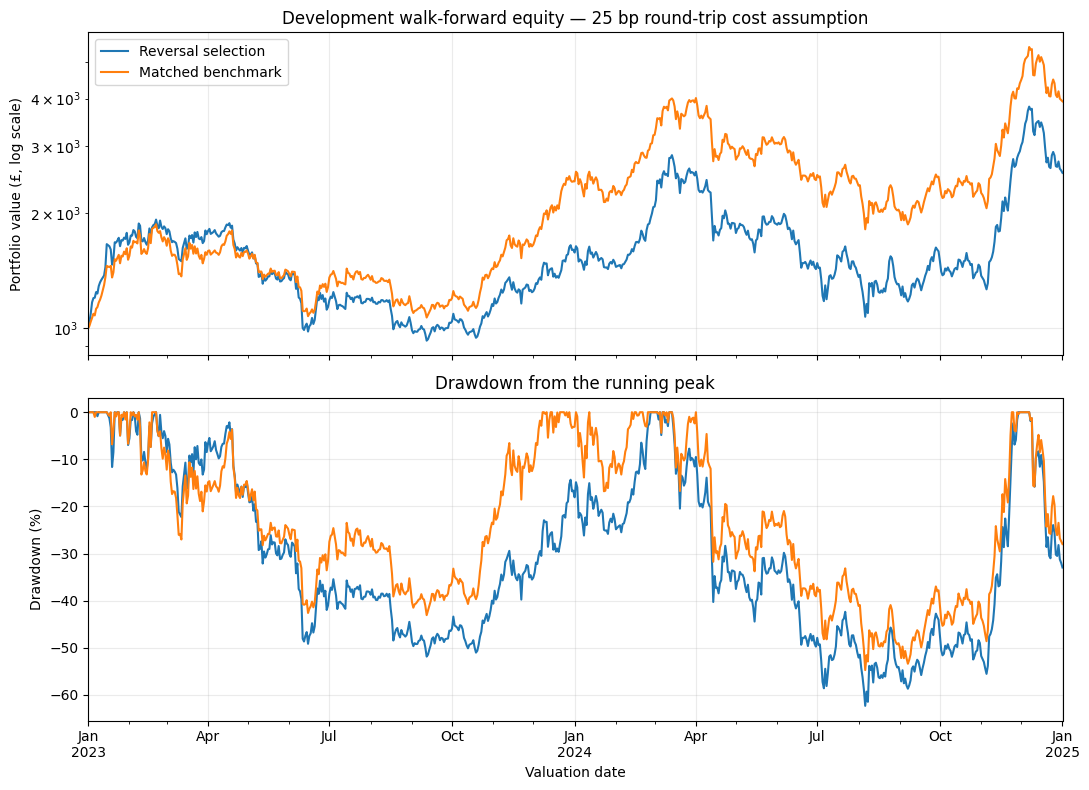

In [ ]:
wf_summary, wf_net_returns, wf_equity = walk_forward_performance.summarise_walk_forward(wf_results, PROTOCOL, WF_RULES)

formats = {"total_return": "{:.2%}",
    "cagr": "{:.2%}",
    "annualised_volatility": "{:.2%}",
    "sharpe_zero_cash_rate": "{:.3f}",
    "max_drawdown": "{:.2%}",
    "mean_daily_net_excess_bps": "{:.3f}",
    "annualised_one_way_turnover": "{:.2f}",
    "final_equity_gbp": "£{:,.2f}"}

display(wf_summary[list(formats)].style.format(formats))
wf_fig, wf_axes, wf_drawdown = walk_forward_performance.plot_walk_forward_equity(wf_equity,WF_RULES)
figure_dir = PROJECT_ROOT / "figures"
figure_dir.mkdir(exist_ok=True)
wf_fig.savefig(figure_dir / "development_walk_forward.png", dpi=150, bbox_inches="tight")

See that the strategy makes money over this period, but performs worse than its matched benchmark. It returns 155.57%, compared with 293.46%, with greater volatility, a lower Sharpe ratio and a worse maximum drawdown. Mean daily net excess is −4.933bp. The equity curves tell the same story as the statistics.

## Conclusion

- See that the strategy makes money, but performs worse than its benchmark under every single metric above. Positive absolute returns alone do not establish an edge.
- The development sweep is weak across configurations and years. It produces lower returns with greater volatility, worse drawdown and more turnover than the matched benchmark.
- The reserved 01/2025–08/2026 holdout was not evaluated, and no bootstrap significance test was run. This is a decision to stop based on unfavourable development evidence, not a claim of statistically significant underperformance.
- The candidate list uses a current universe, leaving survivorship bias. Transaction costs are not verified but rather are a modelling assumption.

There is insufficient evidence to justify using this approach in practice, hence it is shelved.